# *Lab 13 - Edge Detection*

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imgFile = 'kid1.jpg'

# *Sobel Edge Detector*

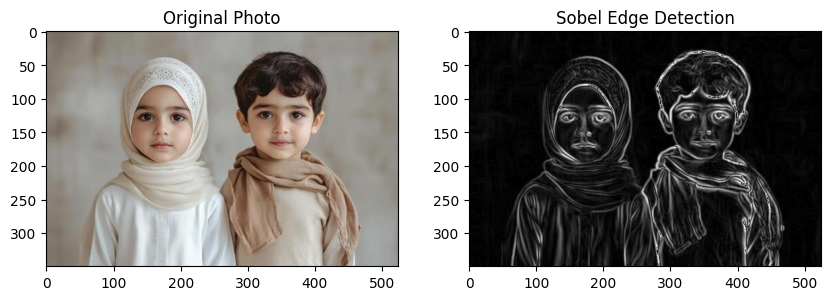

In [2]:
img = cv2.imread(imgFile)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur to reduce noise

blurred = cv2.GaussianBlur(gray, (5, 5), 0) # blurred = img or gray   ## Check the results

# Apply Sobel filter
sobelx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)

# Calculate Magnitude (Final Edge Map)
sobel_combined = cv2.magnitude(sobelx, sobely)

# Normalize to 0-255 for display
sobel_final = np.uint8(np.absolute(sobel_combined))

# Display images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title('Original Photo')
plt.subplot(1, 2, 2), plt.imshow(sobel_final, cmap='gray'), plt.title('Sobel Edge Detection')
plt.show()


# **Robert Edge Detector**

### Comparing to Sobel
   

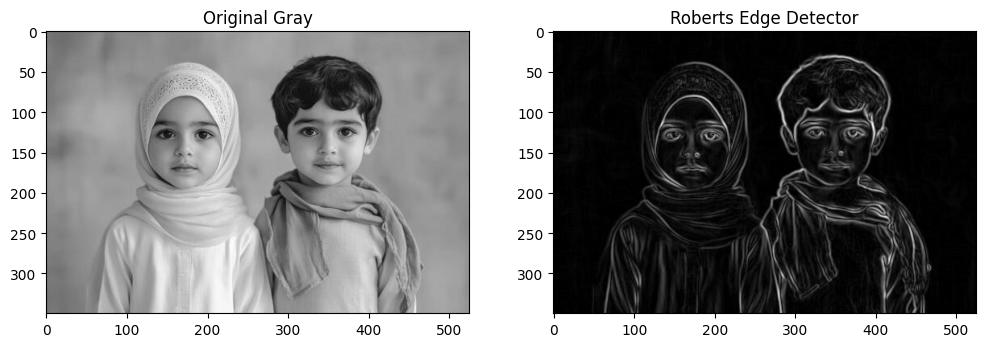

In [3]:
image = cv2.imread(imgFile, 0) 

# Pre-process: Always blur for Roberts
blurred = cv2.GaussianBlur(image, (5, 5), 0)

# Define Roberts Cross kernels
kernel_x = np.array([[1, 0], [0, -1]], dtype=np.float64)
kernel_y = np.array([[0, 1], [-1, 0]], dtype=np.float64)

# Apply kernels using convolution
roberts_x = cv2.filter2D(blurred, cv2.CV_64F, kernel_x)
roberts_y = cv2.filter2D(blurred, cv2.CV_64F, kernel_y)

# Calculate Magnitude (Combine X and Y)
roberts_combined = cv2.magnitude(roberts_x, roberts_y)

# Convert to uint8 for display
roberts_final = np.uint8(np.absolute(roberts_combined))

# Display images
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(image, cmap='gray'), plt.title('Original Gray')
plt.subplot(1, 2, 2), plt.imshow(roberts_final, cmap='gray'), plt.title('Roberts Edge Detector')
plt.show()


## **Prewitt Edge Detector**

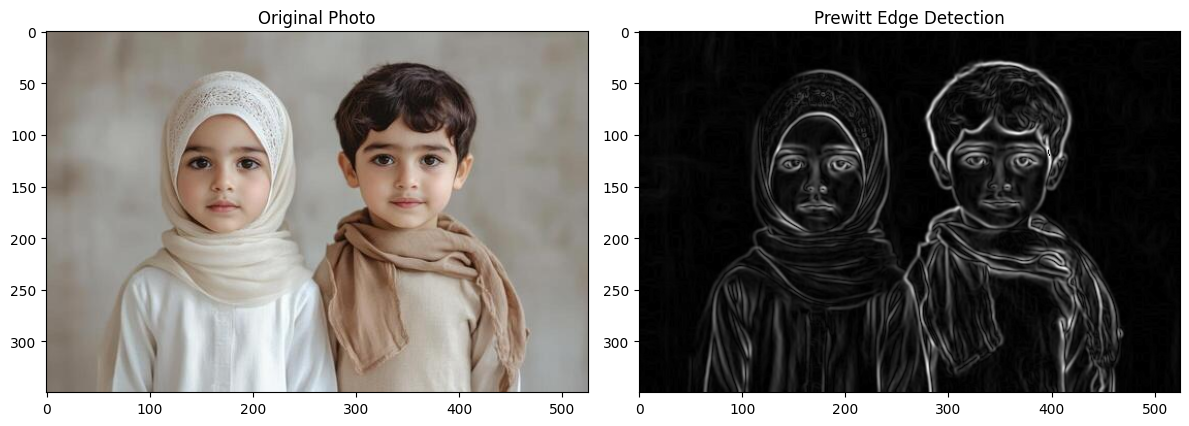

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load a real image in grayscale
img = cv2.imread(imgFile)

# Grayscale & Blur (Essential for real photos to reduce grain)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Define Prewitt Kernels manually
kernel_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float64)
kernel_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float64)

# Apply filters
prewitt_x = cv2.filter2D(blurred, cv2.CV_64F, kernel_x)
prewitt_y = cv2.filter2D(blurred, cv2.CV_64F, kernel_y)

# Calculate Magnitude (Combine X and Y)
prewitt_combined = cv2.magnitude(prewitt_x, prewitt_y)

# Normalize to 8-bit for display
prewitt_final = np.uint8(np.absolute(prewitt_combined))

# Display Images
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title('Original Photo')
plt.subplot(1, 2, 2), plt.imshow(prewitt_final, cmap='gray'), plt.title('Prewitt Edge Detection')
plt.tight_layout()
plt.show()


## **Canny Edge Detector**

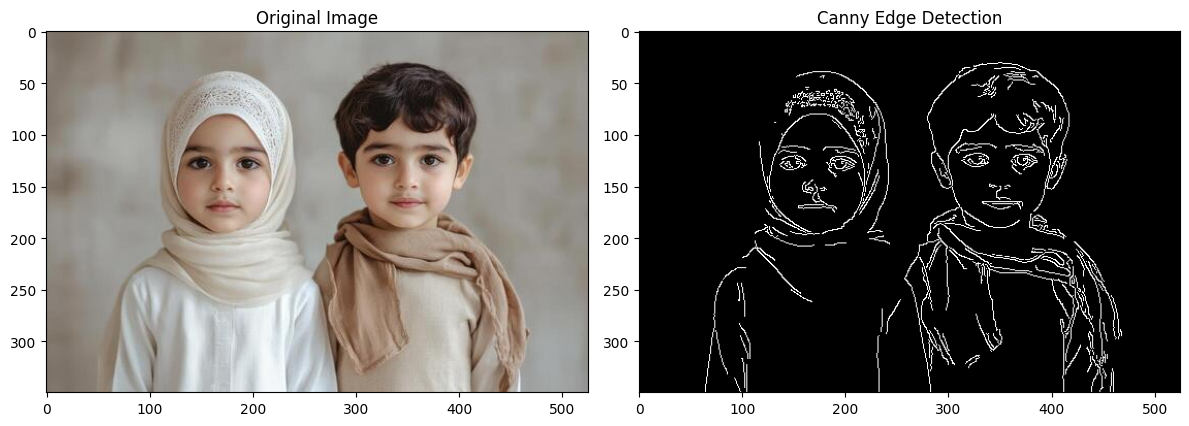

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(imgFile)


# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Canny Edge Detection

canny_edges = cv2.Canny(gray, 100, 200)

# Display images
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title('Original Image')
plt.subplot(1, 2, 2), plt.imshow(canny_edges, cmap='gray'), plt.title('Canny Edge Detection')
plt.tight_layout()
plt.show()


## **Multi-Channel Canny Edge Detector**

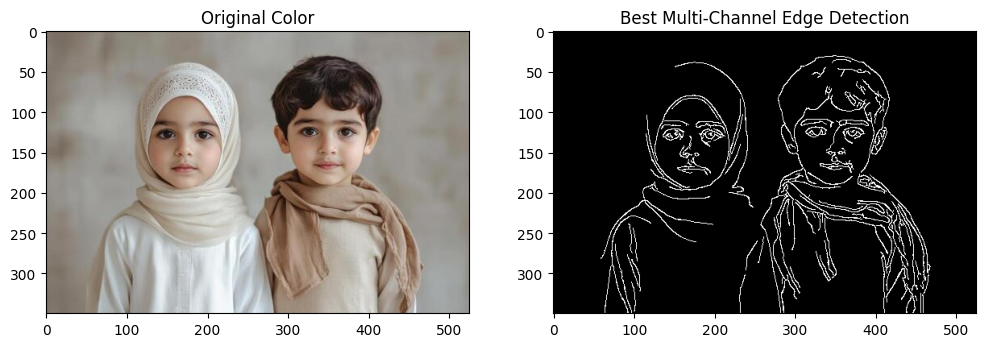

In [6]:

def best_color_edge_detector(image_path):
    # Load the color image
    img = cv2.imread(image_path)
    if img is None:
        return "Image not found."

    channels = cv2.split(img)
    edge_maps = []

    for channel in channels:
        # Pre-process each channel with Gaussian Blur to reduce noise
        blurred = cv2.GaussianBlur(channel, (5, 5), 0)

        # Apply Canny to each channel
        # 50 and 150 are the low and high thresholds
        edges = cv2.Canny(blurred, 50, 150)
        edge_maps.append(edges)

    # Merge edges from all channels using bitwise OR
    # This keeps any edge found in ANY of the three color layers
    combined_edges = cv2.bitwise_or(edge_maps[0], edge_maps[1])
    combined_edges = cv2.bitwise_or(combined_edges, edge_maps[2])

    return img, combined_edges

# Run the detector
original, edges = best_color_edge_detector(imgFile)

# Display images
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB)), plt.title('Original Color')
plt.subplot(1, 2, 2), plt.imshow(edges, cmap='gray'), plt.title('Best Multi-Channel Edge Detection')
plt.show()


## **LoG Filter**

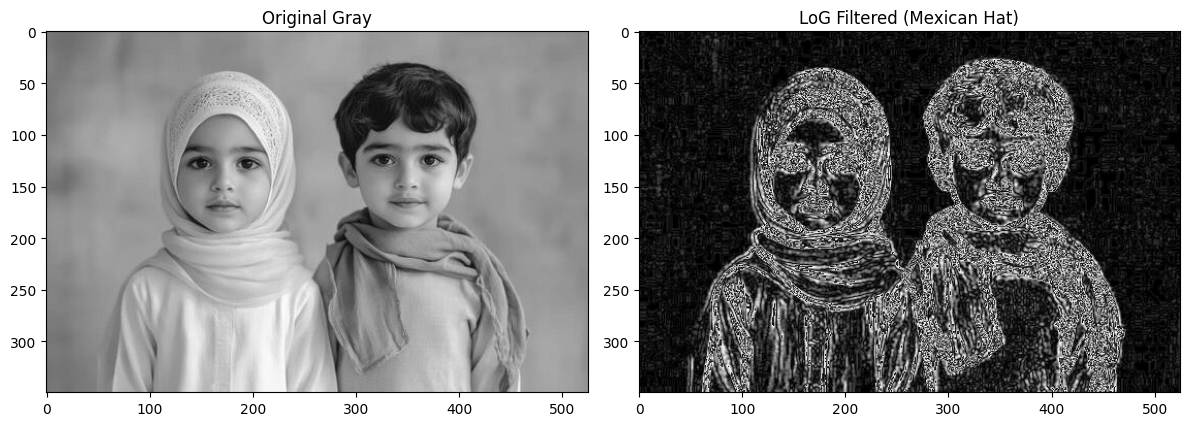

In [7]:
img = cv2.imread(imgFile, cv2.IMREAD_GRAYSCALE)

# Gaussian Blur (Smoothing)
blurred = cv2.GaussianBlur(img, (5, 5), 0)

# Laplacian Operator (Second Derivative)
laplacian = cv2.Laplacian(blurred, cv2.CV_64F, ksize=5)

# Post-processing: Normalize for display
log_final = np.uint8(np.absolute(laplacian))

# display images
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray'), plt.title('Original Gray')
plt.subplot(1, 2, 2), plt.imshow(log_final, cmap='gray'), plt.title('LoG Filtered (Mexican Hat)')
plt.tight_layout()
plt.show()


## **DoG Filter**

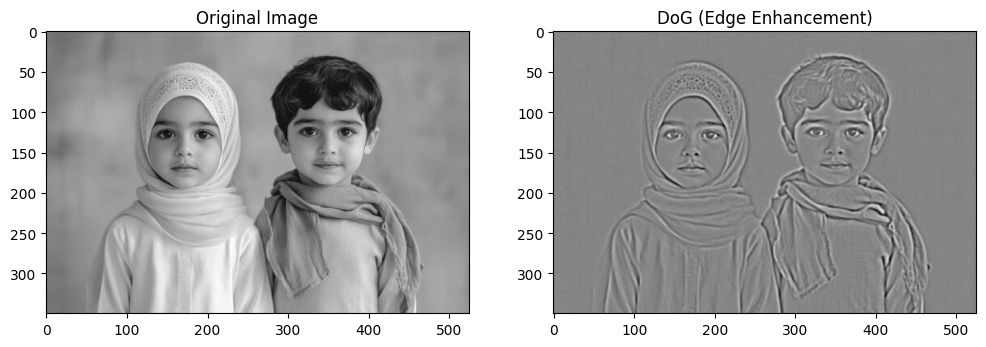

In [8]:
img = cv2.imread(imgFile, cv2.IMREAD_GRAYSCALE)

# Apply two Gaussian blurs with different standard deviations (Sigmas)
# Low sigma preserves detail; High sigma captures broad structure
blur_narrow = cv2.GaussianBlur(img, (0, 0), sigmaX=1.0)
blur_wide = cv2.GaussianBlur(img, (0, 0), sigmaX=2.0)

# Calculate the Difference (DoG)
dog = blur_narrow.astype(np.float32) - blur_wide.astype(np.float32)

# Normalize or Threshold for visibility
dog_normalized = cv2.normalize(dog, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Simple threshold to create a binary edge map
_, dog_binary = cv2.threshold(dog_normalized, 127, 255, cv2.THRESH_BINARY)

# Display images
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray'), plt.title('Original Image')
plt.subplot(1, 2, 2), plt.imshow(dog_normalized, cmap='gray'), plt.title('DoG (Edge Enhancement)')
plt.show()


## **Gradient Edge Detector for Colored Images**

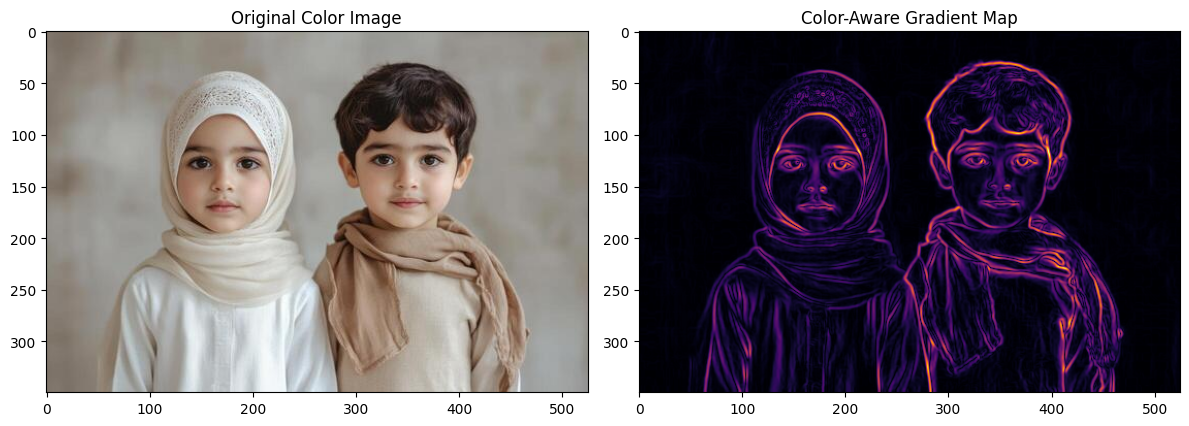

In [9]:
# Load the real-world color image
image = cv2.imread(imgFile)

# Split the image into its R, G, and B components
b, g, r = cv2.split(image)

def get_channel_gradient(channel):
    # Use Sobel for gradient calculation on a single channel
    # Blur first to reduce noise in that specific color layer
    blurred = cv2.GaussianBlur(channel, (3, 3), 0)
    gx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    return cv2.magnitude(gx, gy)

# Compute gradients for each color channel
grad_b = get_channel_gradient(b)
grad_g = get_channel_gradient(g)
grad_r = get_channel_gradient(r)

# Combine gradients from all channels
combined_gradient = np.sqrt(grad_b**2 + grad_g**2 + grad_r**2)

# Normalize to 0-255 for visualization
color_edges = cv2.normalize(combined_gradient, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Display images
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)), plt.title('Original Color Image')
plt.subplot(1, 2, 2), plt.imshow(color_edges, cmap='inferno'), plt.title('Color-Aware Gradient Map')
plt.tight_layout()
plt.show()
